**Business Objective**

The purpose of this investigation is to answer whether deliveries are taking longer and to idenitfy what part of the fulfillment process is experiencing bottlenecks. In addition, I'm introduced to Sarah, my Product Manager (PM).




In [1]:
# Load Cleaned Data

import pandas as pd

customers = pd.read_csv("customers_clean.csv")
orders = pd.read_csv("orders_clean.csv")

**Analyst Commentary**

Sarah's first question: Are deliveries taking longer?

**Planning**

*Business Question:* Are deliveries taking longer?

*Metric:*

- Average delivery time

*Comparison:*

- Compared to previous months

*Visualization:*

- Line chart

*Interpretation:*

- What does the trend tell us?

*Next Investigation:*

- Where is the bottleneck?

In [2]:
# Calculate descriptive statistics for delivery_time_days

orders['delivery_time_days'].describe()

,delivery_time_days
count,96476.000000
mean,12.094842
std,9.551585
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**Analyst Commentary**

Based on the data, 96,476 out of 99,441 rows have a recorded `delivery_time_days` timestamp and 2965 did not. This suggests that these missing rows may have order statuses that are not yet delivered (or is missing its `order_delivered_customer_date` for one of the reasons investigated in Notebook 02).

Mean (12.09) and median (10) are close, but not identical, suggesting a mild right-skew in the data. The minimum (0.0) indicates that these are same-day deliveries. The maximum (209) suggests that the slowest delivery took approximately 7 months. This is plausible, given Notebook 02's investigation, where evidence showed that the 188-day-late order was legitimate. The IQR is 6 - 15 days, meaning that the middle half of orders were delivered within a 9-day window for this dataset, a "typical" range to reference in this investigation.



In [3]:
# What percent of orders were delivered within 6 - 15 days?

pct_in_range = ((orders["delivery_time_days"] >= 6) & (orders["delivery_time_days"] <= 15)).mean() * 100
pct_in_range

np.float64(54.33473114711236)

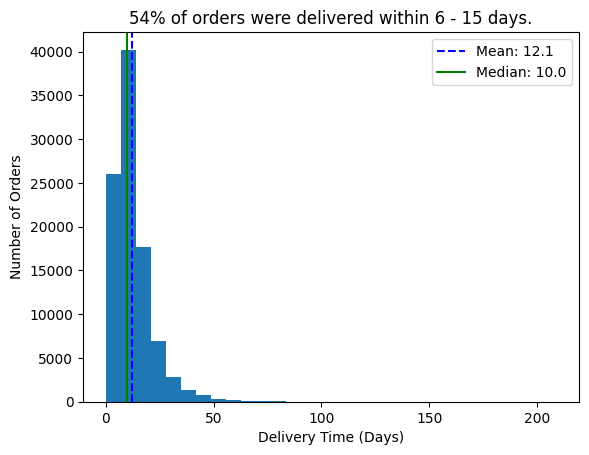

In [4]:
# Create histogram of delivery_time_days

import matplotlib.pyplot as plt

mean_val = orders["delivery_time_days"].mean()
median_val = orders["delivery_time_days"].median()

plt.hist(orders["delivery_time_days"], bins=30)
plt.axvline(mean_val, color="blue", linestyle="--", label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color="green", linestyle="-", label=f"Median: {median_val:.1f}")
plt.title("54% of orders were delivered within 6 - 15 days.")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

**Analyst Commentary**

The distribution of delivery times is right-skewed, with 54% of orders delivered within 6-15 days. A relatively small number of orders experience substantially longer delivery times. Those particular orders may disproportionately affect customer satisfaction even if the average delivery time appears tolerable. Although the histogram provides insight into the overall distribution of delivery times, it does not indicate whether delivery performance has changed over time. A time-series analysis is needed to determine whether deliveries are becoming slower.

The mean is greater than the median, which is consistent with the right-skewed distribution and indicates that a relatively small number of very long delivery times pull the average upward.

To see the average delivery time over time, plotting a monthly trend could represent that relationship.

In [5]:
# What are the delivery_time_days by month?

orders.groupby("order_month")["delivery_time_days"].count()

,delivery_time_days
order_month,
2016-09-01,1
2016-10-01,270
2016-12-01,1
2017-01-01,750
2017-02-01,1653
2017-03-01,2546
2017-04-01,2303
2017-05-01,3545
2017-06-01,3135


**Analyst Commentary**

2018-09 and 2018-10 have 0 `delivery_time_days`. This could suggest that the dataset's delivery data may have been pulled while some orders may not have completed the entirety of the fulfillment process. Since these months have 0 `delivery_time_days`, it would be worth dropping these months from the visual, since a missing value can be misrepresented in this context as "these orders weren't tracked" versus "these orders just had not been delivered yet when this data was pulled." Need to investigate further to verify this hypothesis.

In [6]:
# What are the order statuses of orders made in September 2018?

orders.loc[orders["order_month"] == "2018-09-01", "order_status"].value_counts()

,count
order_status,
canceled,15
shipped,1


In [7]:
# What are the order statuses of orders made in October 2018?

orders.loc[orders["order_month"] == "2018-10-01", "order_status"].value_counts()

,count
order_status,
canceled,4


**Analyst Commentary**

For September and October 2018, the order statuses confirm that the `delivery_time_days` were 0 because these 20 orders had order statuses that were either canceled or shipped. Logically, these statuses will not have a `delivery_time_days` value due to where they are in the fulfillment process. Therefore, this is not a data quality problem because there was no valid delivery time to measure, when the data was pulled.

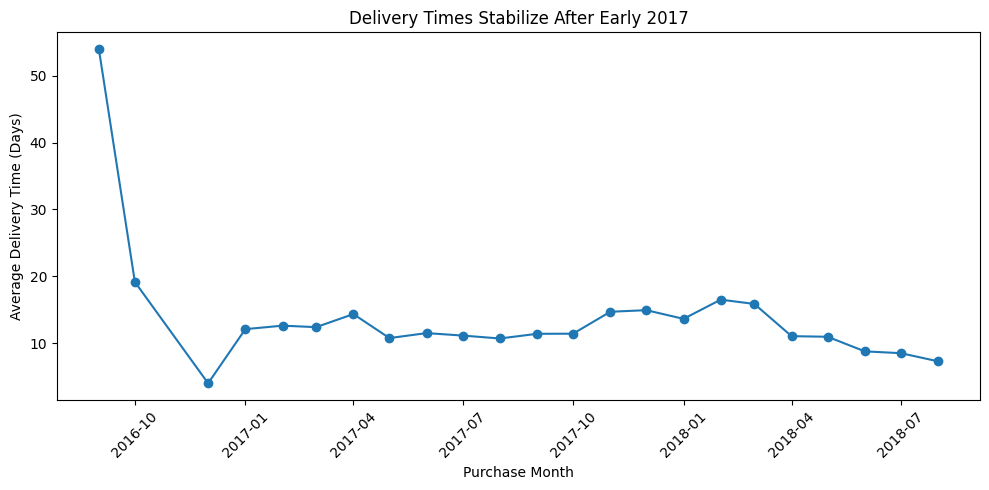

In [8]:
# Determining Monthly Trend by Average Delivery Time Over Time

# Convert order_purchase_timestamp to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")

# Create a monthly trend (using purchase month) showing average delivery time over time
orders["order_month"] = (orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
monthly_avg = (
    orders.groupby("order_month", as_index=True)
          .agg(avg_delivery_days=("delivery_time_days", "mean"))
)

monthly_avg = monthly_avg.dropna()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_avg.index,
    monthly_avg["avg_delivery_days"],
    marker="o"
)

plt.title("Delivery Times Stabilize After Early 2017")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Analyst Commentary**

The monthly average delivery time declined sharply between late 2016 and early 2017 before stabilizing around 10-15 days throughout most of 2017 and 2018. Based on the available data, there is no clear evidence of a sustained upward trend in delivery times during the later portion of the dataset. Instead, delivery performance appears relatively stable after the initial improvement.



**Follow-up Questions:**

- Which stage of fulfillment contributes most to delivery time?

- Are longer delivery times associated with late deliveries or approval delays?

**Key Takeaways:**

1. Most customers will receive their orders within 6-15 days.
2. A relatively small number of orders experience substantially longer delivery times.
3. Those relatively small number of orders may disproportionately affect customer satisfaction even if the average delivery time appears tolerable.

**Analyst Commentary**

Sarah's second question: Which state of the fulfillment process contributes the most to overall fulfillment time?

**Planning**

*Business Question:* Which stage of the fulfillment process contributes the most to overall fulfillment time?

*Metric:*
* Mean fulfillment time
* Median fulfillment time
* approval_time_hours
* carrier_time_hours
* delivery_time_days

*Comparison:* Compare the average and median duration of each fulfillment stage to identify which stage contributes most to the overall delivery timeline.

*Visualization:* Horizontal bar chart comparing the average and/or median duration of each fulfillment state.

*Interpretation:*
*   Which fulfillment stage takes the longest?
*   Does the mean differ substantially from the median?
*   Are there signs of extreme outliers?
*   Which stage should Sarah investigate first?

*Next Investigation:* Why is that stage slower?

In [9]:
# Calculate Summary Statistics for each engineered feature chosen for this investigation

orders[["approval_time_hours", "carrier_time_hours", "delivery_time_days"]].describe()

,approval_time_hours,carrier_time_hours,delivery_time_days
count,99281.000000,97644.000000,96476.000000
mean,10.419094,67.302436,12.094842
std,26.038004,85.147344,9.551585
min,0.000000,-4109.256111,0.000000
25%,0.215000,21.012222,6.000000
50%,0.343333,43.639583,10.000000
75%,14.580833,85.924931,15.000000
max,4509.180556,3018.301667,209.000000


**Analyst Commentary**

`carrier_time_hours` min is -4109. A negative value here means that the carrier handoff was recorded as happening before it was even approved. This was explored in Notebook 02 (1359 rows where `order_delivered_carrier_date` < `order_approved_at`).

Mean and std were calculated on `carrier_time_hours` which pulled from these negative values. Mean being 67.3 suggest a typical carrier handoff time, since it's averaged with over a thousand rows that are negative (which is impossible) due to the source-system logging gap rather than fast handoffs.

Note: This anomaly stems from the previously documented source-system logging anomaly described in Notebook 02. These records remain preserved in the cleaned dataset but they will be excluded from analyses requiring logically ordered fulfilment stages.

In [10]:
# What's the impact of this anomaly?

(orders["carrier_time_hours"] < 0).sum()

np.int64(1359)

In [11]:
# Recalculate the table, excluding these known bad rows

clean_orders = orders[orders["carrier_time_hours"] >= 0]
clean_orders[["approval_time_hours", "carrier_time_hours", "delivery_time_days"]].describe()

,approval_time_hours,carrier_time_hours,delivery_time_days
count,96285.000000,96285.000000,95111.000000
mean,9.666832,68.601724,12.152727
std,19.274728,83.926039,9.576974
min,0.000000,0.004167,0.000000
25%,0.214444,21.636944,6.000000
50%,0.338056,44.435556,10.000000
75%,13.570278,86.966111,15.000000
max,784.045556,3018.301667,209.000000


**Analyst Commentary**

Because the 1359 rows resulted from a documented source-system logging gap (see Notebook 2), they produced negative carrier handoff durations. Filtering to values greater than or equal to zero limits this analysis to logically interpretable fulfillment stages.

Comparing this summary table to the previous one, `carrier_time_hours` made small changes. Mean went from 67.3 to 68.6. Std decreased slightly (85.1 to 83.9). The real fix here is that the min is logically valid (0.004 hours versus -4109). The max on `approval_time_hours` dropped immensely (4509 to 784), suggesting that many of those same problematic rows had impossible approval-time values, too.

In conclusion, excluding 1359 rows had minimal effect on the mean. The action, instead, removed logically impossible negative and extreme outlier values, improving the reliability of min/max reporting.

Note: The 1,359 rows meaningfully affect `carrier_time_hours` and `approval_time_hours` but has negligible impact on `delivery_time_days` (mean shift of 0.06 days; monthly averages shift by at most 0.21 days). Prior analyses using `delivery_time_days` — including the monthly trend and distribution histogram — remain valid without correction. In addition, this anomaly stems from the previously documented source-system logging anomaly described in Notebook 02. These records remain preserved in the cleaned dataset but are excluded from analyses requiring logically ordered fulfilment stages.

In [12]:
# Comparing fulfillment stages

# Convert delivery_time_days to hours
clean_orders = clean_orders.copy()
clean_orders["delivery_time_hours"] = clean_orders["delivery_time_days"] * 24

# Which stage has the highest median duration? Highest average duration? The greatest variability?
clean_orders[["approval_time_hours", "carrier_time_hours", "delivery_time_hours"]].agg(["mean", "median", "std"])


,approval_time_hours,carrier_time_hours,delivery_time_hours
mean,9.666832,68.601724,291.665444
median,0.338056,44.435556,240.000000
std,19.274728,83.926039,229.847370


**Analyst Commentary**

Highest median duration: `delivery_time_hours` = 240 hours (10 days). Time from purchase to customer delivery includes the approval and carrier stages, so this makes sense within the fulfillment process and confirms the longer total duration is expected because it encompasses multiple fulfillment stages.

Highest average duration: `delivery_time_hours` = 291.7 hours. Same reasoning and is consistent with median.

For greatest variability, is `delivery_time_hours` proportionately more variable compared to other fulfillment stages or just bigger?

In [13]:
# Is delivery_time_hours proportionately more variable, or just bigger?

result = clean_orders[["approval_time_hours", "carrier_time_hours", "delivery_time_hours"]].agg(["mean", "median", "std"])
cv = result.loc["std"] / result.loc["mean"]
print(cv)

approval_time_hours    1.993903
carrier_time_hours     1.223381
delivery_time_hours    0.788051
dtype: float64


**Analyst Commentary**

Greatest variability: `approval_time_hours`. `delivery_time_hours` had the largest std in absolute terms due to being a measure on a much bigger scale. However, relative to its typical size, it's the most consistent out of the three fulfillment stages (CV of 0.79, so std is 79% of its mean).

`approval_time_hours` has a CV of nearly 2.0 and its std is almost twice its own mean. This suggests that there's inconsistency. Some orders get approved right away, whereas others take extremely longer, proportionally speaking.

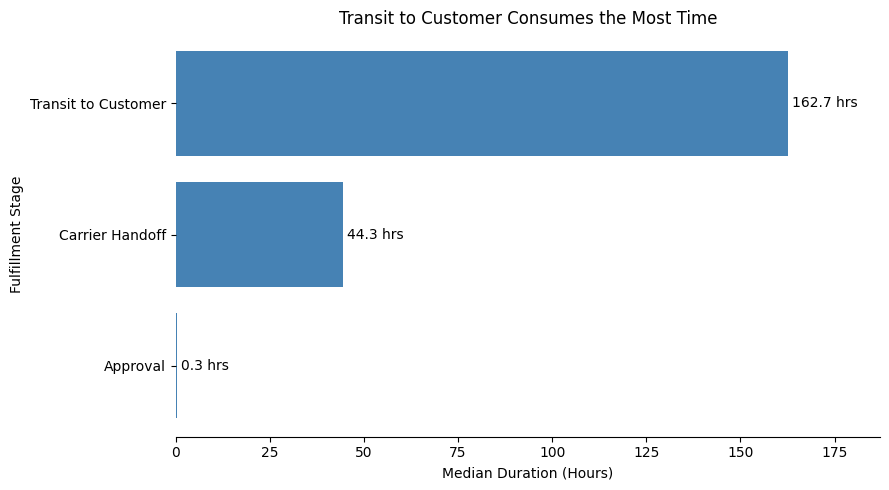

In [14]:
# Create a visualization

clean_orders = orders[orders["carrier_time_hours"] >= 0].copy()
clean_orders["delivery_time_hours"] = clean_orders["delivery_time_days"] * 24
clean_orders["carrier_to_delivery_hours"] = clean_orders["delivery_time_hours"] - (
    clean_orders["approval_time_hours"] + clean_orders["carrier_time_hours"]
)

# Exclude rows where the isolated transit stage is negative
clean_orders = clean_orders[clean_orders["carrier_to_delivery_hours"] >= 0]

medians = clean_orders[["approval_time_hours", "carrier_time_hours", "carrier_to_delivery_hours"]].median()
medians = medians.rename({
    "approval_time_hours": "Approval",
    "carrier_time_hours": "Carrier Handoff",
    "carrier_to_delivery_hours": "Transit to Customer"
})

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(medians.index, medians.values, color="steelblue")
ax.bar_label(bars, fmt="%.1f hrs", padding=3)

# Remove left and right borders (spines)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Give a little extra room on the x-axis so labels aren't cut off
ax.set_xlim(0, medians.max() * 1.15)

ax.set_title("Transit to Customer Consumes the Most Time")
ax.set_xlabel("Median Duration (Hours)")
ax.set_ylabel("Fulfillment Stage")
plt.tight_layout()
plt.show()

**Analyst Commentary**

From the bar chart, transit to customer consumes the most time. The transit to customer is the largest share of overall fulfillment time, when compared with the approval and carrier handoff stages. Sarah should care about this because deliveries that are inconsistent could impact customer satisfaction.

**Business Recommendation**

Since the transit to customer stage consumes the majority of fulfillment time, the operations team should investigate which components of the transit to customer stage contribute most to customer wait times. This may include shipping distance, carrier performance, or regional logistics.

**Questions for Further Investigation**

Questions Answerable with Existing Data
1. Do late deliveries correspond to lower review scores?

2. Is there a trend of longer delivery times by region?

3. Do delivery times vary by month?

Questions Requiring Additional Operational Data

1. How much time is spent in warehouse processing?

2. Which shipping partners contribute most to long delivery times?

**Analyst Commentary**

This investigation established that operational performance remained relatively stable over time and identified transit to customer as the longest stage of the fulfillment process. While these findings describe how the fulfillment process performs operationally, they do not explain how customers perceive that experience. The next investigation shifts from operational performance to customer satisfaction to determine whether delivery performance influences review scores and to identify opportunities for improving the customer experience.